# MODELISATION DES REMBOURSEMENTS ANTICIPES (ER) - IFRS9

## Contexte
Projet de Fin d'Etudes - Modelisation du taux de remboursement anticipe pour predire l'evolution future des encours

## Formule ER
**ER = RA / Encours**

avec **Encours = Capital_emprunt - Montant_rembourse**

## Etapes
1. Calcul de l'encours et de l'ER observe
2. Analyse exploratoire et visualisations
3. Segmentation par clustering
4. Modelisation (Arbres, Random Forest, Gradient Boosting)
5. Comparaison des modeles

## IMPORT DES BIBLIOTHEQUES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliotheques importees avec succes")

Bibliotheques importees avec succes


## SECTION 1 : CHARGEMENT ET PREPARATION DES DONNEES

In [2]:
# Chargement
df = pd.read_excel("Base_ER_FR.xlsx")
print(f"Dataset charge : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Nettoyage de base
cols_to_drop = ["Unnamed: 19", "MREVAU", "MREVNU"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# Conversion date
df["DARRET"] = pd.to_datetime(df["DARRET"].astype(str) + "01", format="%Y%m%d", errors="coerce")

# EAD (garde pour reference mais on utilisera Encours)
if "E_EAD" in df.columns:
    df["EAD"] = df["E_EAD"]
    df.drop(columns=["E_EAD", "E_ONB"], inplace=True, errors="ignore")

df = df[df.get("EAD", 1) > 0]
df["RA"] = df["RA"].fillna(0)

# Variables categorielles
cat_cols = ["CLASSACT", "CSP", "produit"]
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype("category")

# Imputation
df["Tx"] = df.groupby("produit", observed=True)["Tx"].transform(lambda x: x.fillna(x.median()))
df["Tx"] = df["Tx"].fillna(df["Tx"].median())
df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
df["CSP"] = df["CSP"].fillna("Inconnu")
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())

# Features engineering
df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]
df = df[df["AGE_PRET"] >= 0]
df = df[df["AGE_PRET"] <= df["B_MAT"]]
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

print("Preparation des donnees terminee")

Dataset charge : 100000 lignes, 20 colonnes
Preparation des donnees terminee


## SECTION 2 : CALCUL DE L'ENCOURS ET DE L'ER

**FORMULE CORRECTE :**
- Encours = Capital_emprunt - Montant_rembourse
- ER = RA / Encours

In [3]:
# 1. Capital initial emprunte (formule des annuites)
df["Capital_emprunt"] = df["MTECH"] * ((1 - (1 + (df["Tx"] / 1200)) ** (-df["NB_ECH"])) / (df["Tx"] / 1200))

# 2. Montant deja rembourse
df["Montant_rembourse"] = ((df["B_MAT"] - df["B_RESMAT"]) * df["MTECH"].clip(lower=0)).round(2)

# 3. ENCOURS = Capital restant du AVANT le remboursement anticipe
df["Encours"] = df["Capital_emprunt"] - df["Montant_rembourse"]
df["Encours"] = df["Encours"].clip(lower=1)  # Eviter division par zero

# 4. ER = RA / Encours (FORMULE CORRECTE)
df["ER_obs"] = df["RA"] / df["Encours"]
df["ER_obs"] = df["ER_obs"].clip(lower=0, upper=1)

# 5. FLAG_ER (indicateur binaire de remboursement anticipe)
df["FLAG_ER"] = (df["RA"] > 0).astype(int)

# Statistiques
print("Statistiques de l'Encours :")
print(df["Encours"].describe())
print("\nStatistiques de l'ER observe :")
print(df["ER_obs"].describe())
print(f"\nTaux de remboursement anticipe (FLAG_ER = 1) : {df['FLAG_ER'].mean():.2%}")

# Filtrer les outliers extremes
df = df[df["ER_obs"] <= 1]
df = df[df["Encours"] > 0]

print(f"\nNombre de lignes apres nettoyage : {len(df)}")

Statistiques de l'Encours :
count     26519.000000
mean       4192.607053
std       12085.840500
min           1.000000
25%           1.000000
50%           1.000000
75%        3054.488362
max      267674.608804
Name: Encours, dtype: float64

Statistiques de l'ER observe :
count    26519.000000
mean         0.781857
std          0.365925
min          0.000000
25%          0.571395
50%          1.000000
75%          1.000000
max          1.000000
Name: ER_obs, dtype: float64

Taux de remboursement anticipe (FLAG_ER = 1) : 97.10%

Nombre de lignes apres nettoyage : 26519


## SECTION 3 : ANALYSE EXPLORATOIRE

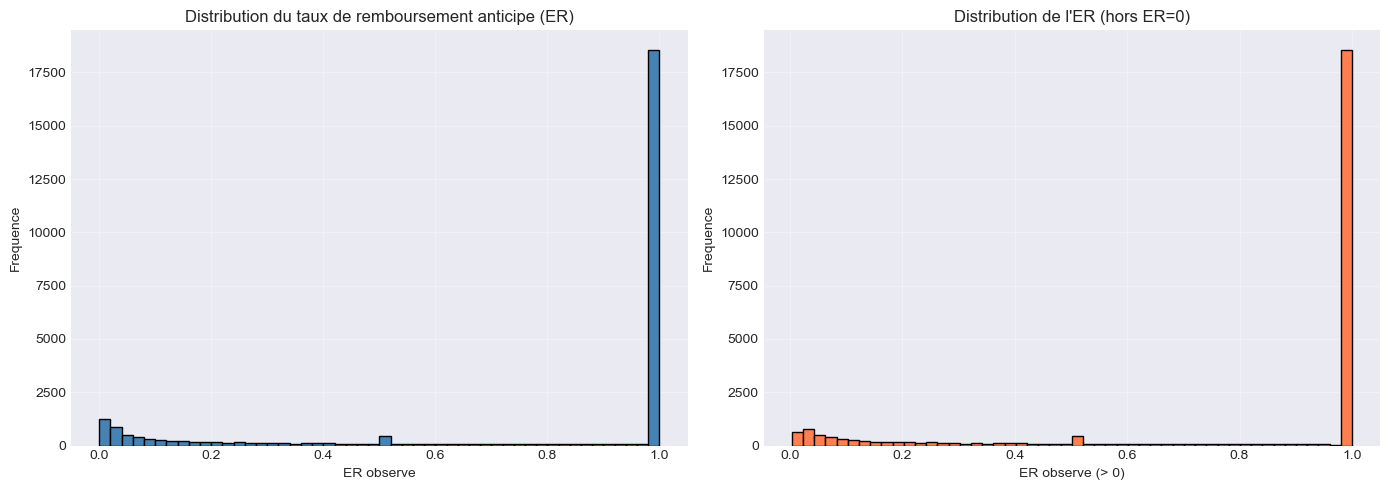

In [4]:
# Graphique 1 : Distribution de l'ER
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["ER_obs"], bins=50, edgecolor='black', color='steelblue')
axes[0].set_xlabel('ER observe')
axes[0].set_ylabel('Frequence')
axes[0].set_title('Distribution du taux de remboursement anticipe (ER)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df[df["ER_obs"] > 0]["ER_obs"], bins=50, edgecolor='black', color='coral')
axes[1].set_xlabel('ER observe (> 0)')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Distribution de l\'ER (hors ER=0)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

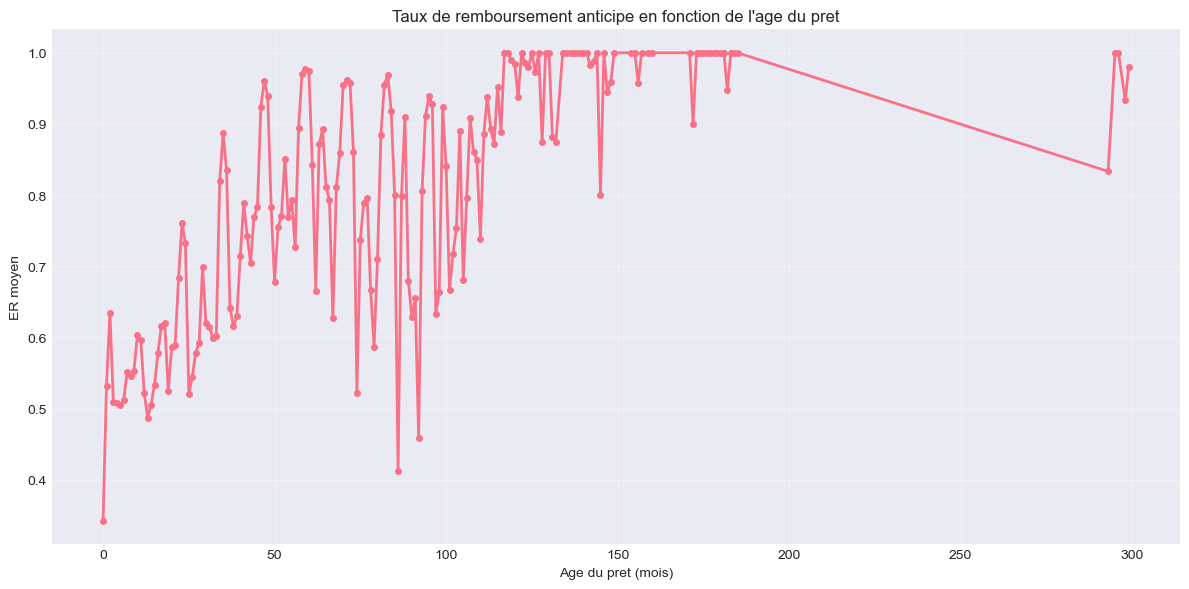

In [5]:
# Graphique 2 : ER en fonction de l'age du pret
er_by_age = df.groupby("AGE_PRET")["ER_obs"].agg(['mean', 'count']).reset_index()
er_by_age = er_by_age[er_by_age['count'] >= 5]

plt.figure(figsize=(12, 6))
plt.plot(er_by_age["AGE_PRET"], er_by_age["mean"], linewidth=2, marker='o', markersize=4)
plt.xlabel('Age du pret (mois)')
plt.ylabel('ER moyen')
plt.title('Taux de remboursement anticipe en fonction de l\'age du pret')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

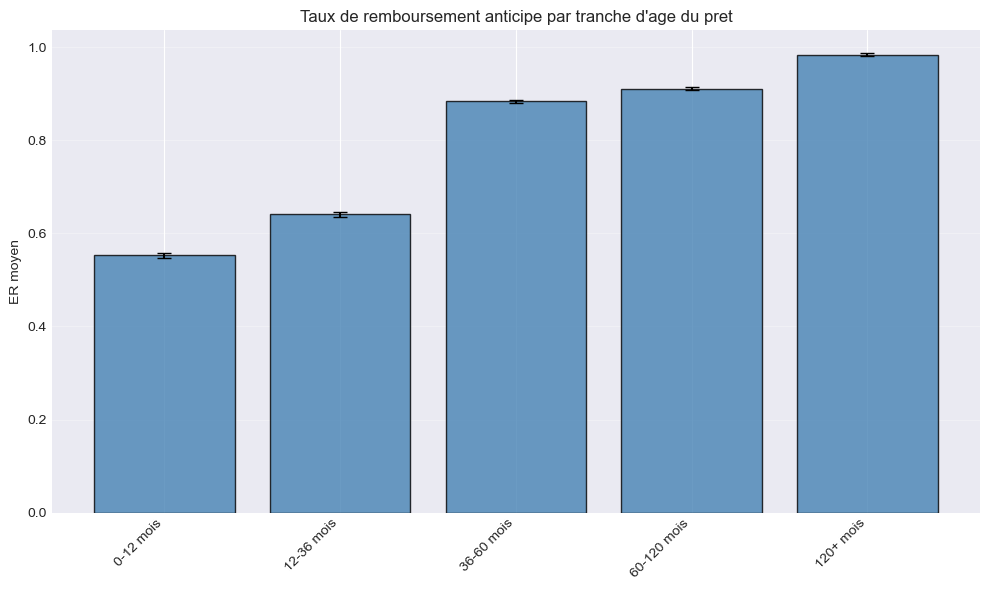

In [6]:
# Graphique 3 : ER par tranches d'age
bins_age = [0, 12, 36, 60, 120, float('inf')]
labels_age = ['0-12 mois', '12-36 mois', '36-60 mois', '60-120 mois', '120+ mois']
df['age_bin'] = pd.cut(df['AGE_PRET'], bins=bins_age, labels=labels_age, right=False)

er_by_bin = df.groupby('age_bin', observed=True)['ER_obs'].agg(['mean', 'std', 'count']).reset_index()

plt.figure(figsize=(10, 6))
x_pos = range(len(er_by_bin))
plt.bar(x_pos, er_by_bin['mean'], yerr=er_by_bin['std']/np.sqrt(er_by_bin['count']),
        capsize=5, color='steelblue', edgecolor='black', alpha=0.8)
plt.xticks(x_pos, er_by_bin['age_bin'], rotation=45, ha='right')
plt.ylabel('ER moyen')
plt.title('Taux de remboursement anticipe par tranche d\'age du pret')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

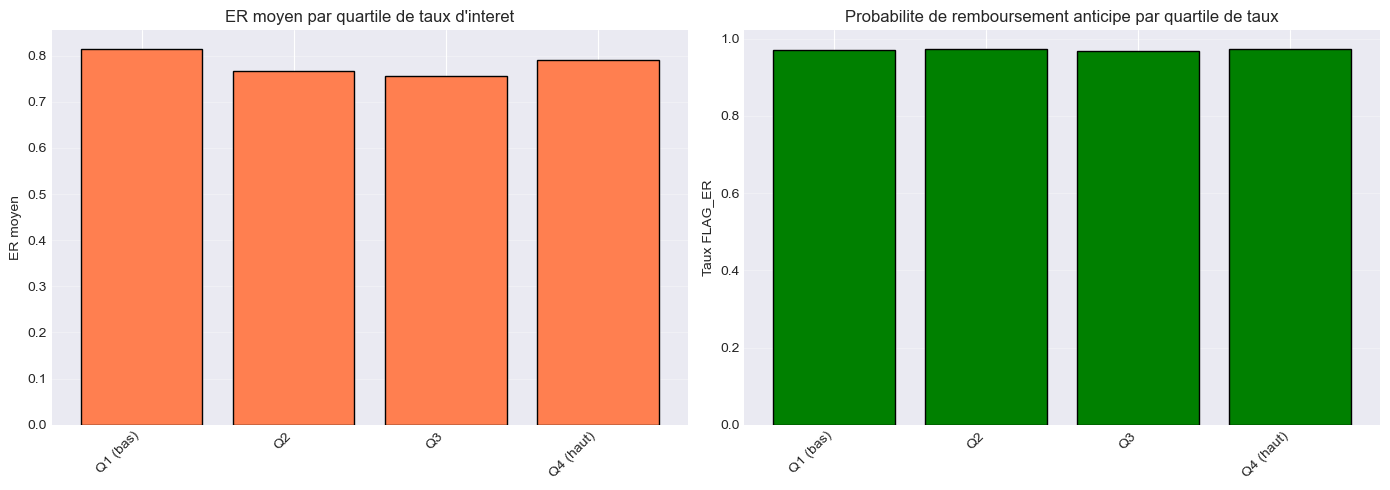

In [7]:
# Graphique 4 : ER en fonction du taux d'interet
df['tx_bin'] = pd.qcut(df['Tx'], q=4, labels=['Q1 (bas)', 'Q2', 'Q3', 'Q4 (haut)'], duplicates='drop')
er_by_tx = df.groupby('tx_bin', observed=True).agg(
    er_moyen=('ER_obs', 'mean'),
    taux_ER=('FLAG_ER', 'mean'),
    n_obs=('ER_obs', 'size')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(er_by_tx)), er_by_tx['er_moyen'], color='coral', edgecolor='black')
axes[0].set_xticks(range(len(er_by_tx)))
axes[0].set_xticklabels(er_by_tx['tx_bin'], rotation=45, ha='right')
axes[0].set_ylabel('ER moyen')
axes[0].set_title('ER moyen par quartile de taux d\'interet')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(len(er_by_tx)), er_by_tx['taux_ER'], color='green', edgecolor='black')
axes[1].set_xticks(range(len(er_by_tx)))
axes[1].set_xticklabels(er_by_tx['tx_bin'], rotation=45, ha='right')
axes[1].set_ylabel('Taux FLAG_ER')
axes[1].set_title('Probabilite de remboursement anticipe par quartile de taux')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## SECTION 4 : CLUSTERING - SEGMENTATION DU PORTEFEUILLE

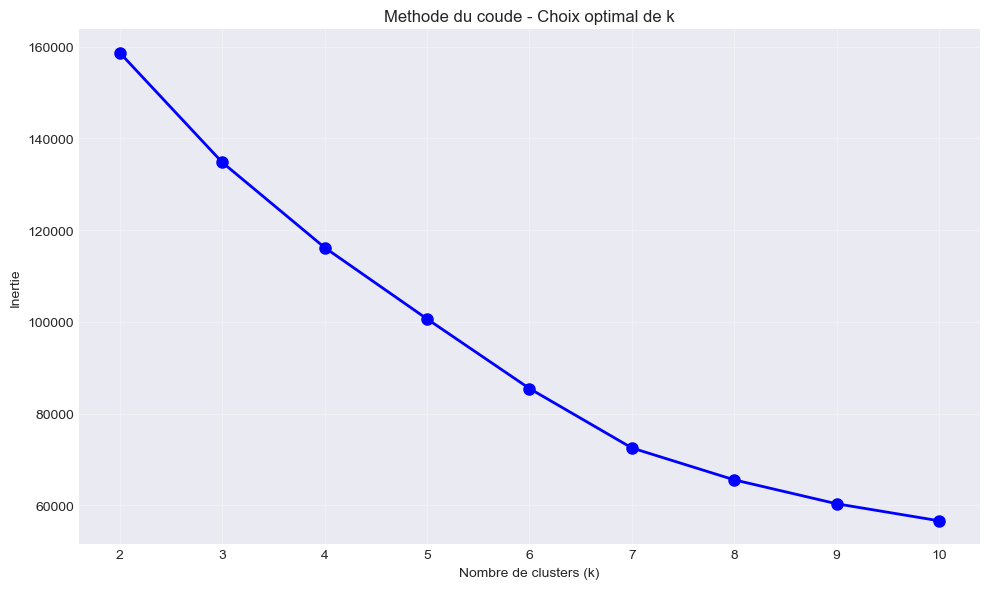

In [8]:
# Features pour le clustering
cluster_features = [
    'AGE_PRET', 'HORIZON_RES', 'Tx', 'MREVTOT', 
    'Capital_emprunt', 'Encours', 'AGE_CLI', 'NB_ECH'
]

df_cluster = df[cluster_features].fillna(0)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(df_cluster)

# Methode du coude pour choisir k
inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Methode du coude - Choix optimal de k')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Clustering avec k=4
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(f"Clustering effectue avec k={k_optimal} clusters")
print("\nRepartition des clusters :")
print(df['Cluster'].value_counts().sort_index())

# Analyse descriptive par cluster
cluster_analysis = df.groupby('Cluster').agg({
    'AGE_PRET': 'mean',
    'HORIZON_RES': 'mean',
    'Tx': 'mean',
    'MREVTOT': 'mean',
    'Capital_emprunt': 'mean',
    'Encours': 'mean',
    'NB_ECH': 'mean',
    'ER_obs': 'mean',
    'FLAG_ER': 'mean',
    'AGE_CLI': 'mean'
}).round(2)

print("\nAnalyse descriptive par cluster :")
print(cluster_analysis)

Clustering effectue avec k=4 clusters

Repartition des clusters :
Cluster
0    11743
1     2788
2    11633
3      355
Name: count, dtype: int64

Analyse descriptive par cluster :
         AGE_PRET  HORIZON_RES    Tx  MREVTOT  Capital_emprunt   Encours  \
Cluster                                                                    
0           38.49        16.58  2.17  2620.38          5385.99   2004.85   
1           28.35       110.06  2.18  2729.55         40005.40  27404.17   
2           67.96         9.86  2.17  2557.68          6451.73    959.72   
3            1.32         1.08 -1.47   477.28           440.28    206.98   

         NB_ECH  ER_obs  FLAG_ER  AGE_CLI  
Cluster                                    
0         37.19    0.78     0.97    39.10  
1        135.62    0.35     0.94    54.46  
2         38.28    0.89     0.98    63.55  
3          2.41    0.68     0.98    40.39  


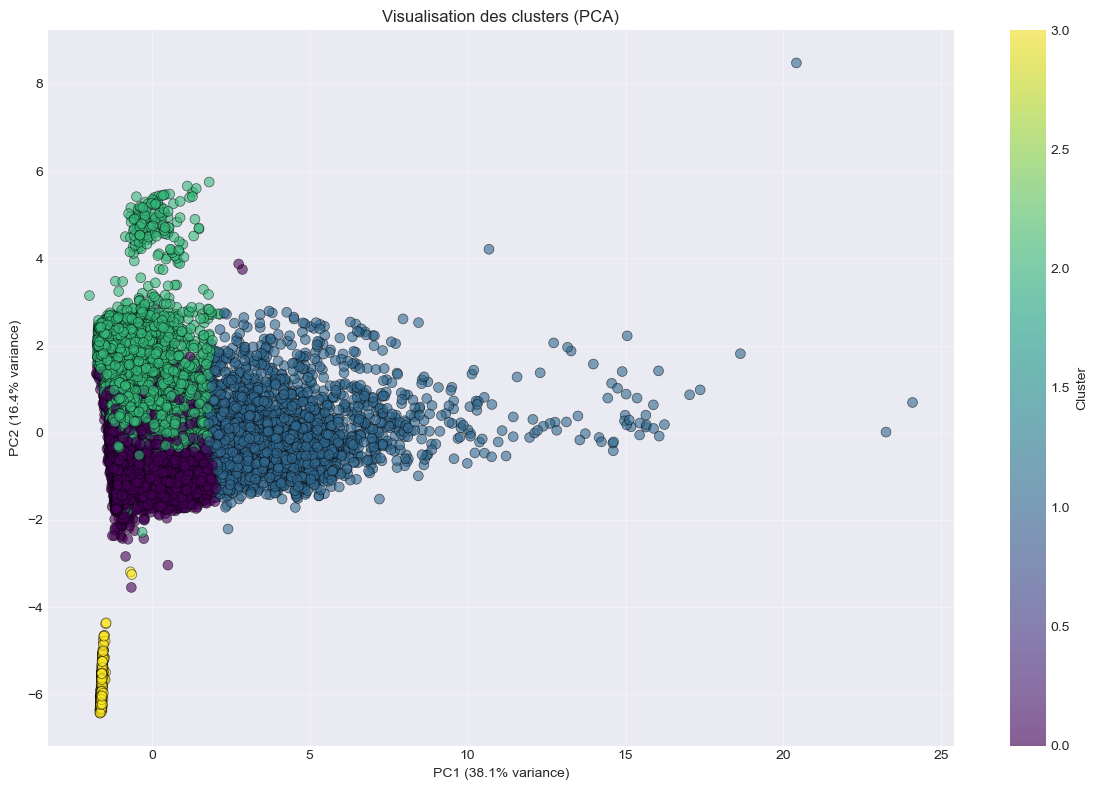

In [10]:
# Visualisation PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], 
                     cmap='viridis', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Visualisation des clusters (PCA)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

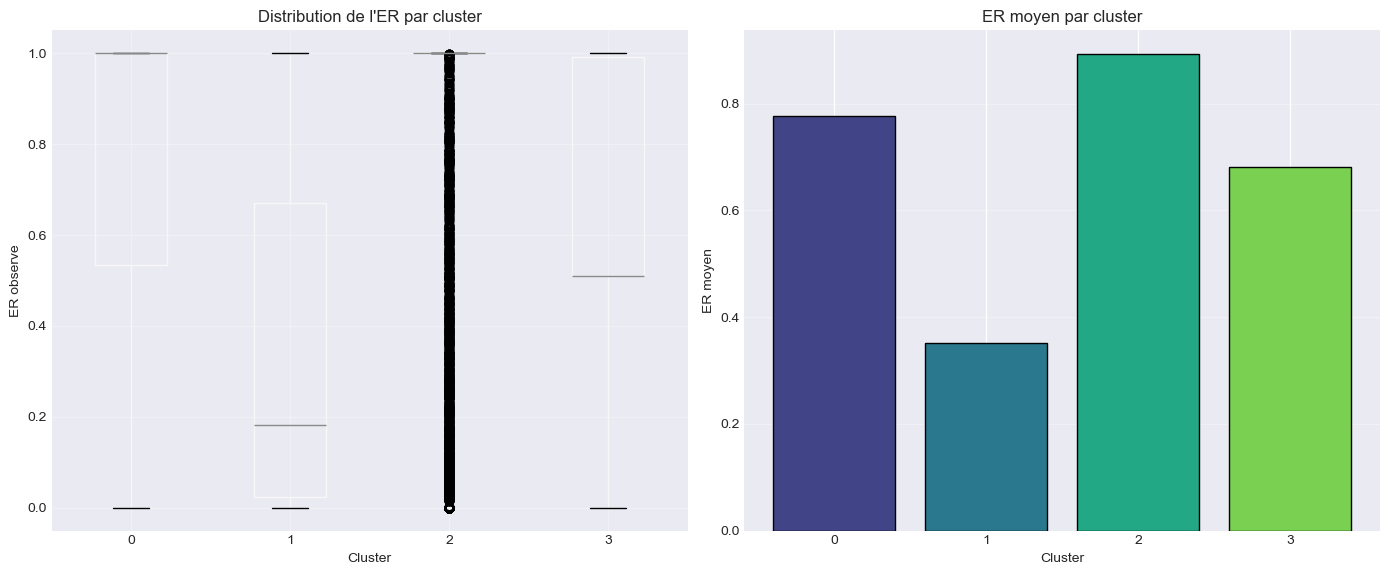

In [11]:
# ER par cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df.boxplot(column='ER_obs', by='Cluster', ax=axes[0])
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('ER observe')
axes[0].set_title('Distribution de l\'ER par cluster')
axes[0].get_figure().suptitle('')
axes[0].grid(True, alpha=0.3)

cluster_er = df.groupby('Cluster')['ER_obs'].mean()
axes[1].bar(range(k_optimal), cluster_er, color=sns.color_palette("viridis", k_optimal), edgecolor='black')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('ER moyen')
axes[1].set_title('ER moyen par cluster')
axes[1].set_xticks(range(k_optimal))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## SECTION 5 : PREPARATION POUR LA MODELISATION

In [12]:
# Encodage des variables categorielles
for col in ['CLASSACT', 'CSP', 'produit']:
    if col in df.columns:
        le = LabelEncoder()
        df[f"{col}_encoded"] = le.fit_transform(df[col].astype(str))

# Features pour la modelisation
model_features = [
    'AGE_PRET', 'HORIZON_RES', 'Tx', 'MREVTOT', 'Capital_emprunt',
    'Encours', 'AGE_CLI', 'NB_ECH', 'CLASSACT_encoded', 'CSP_encoded', 
    'produit_encoded', 'MTECH', 'NBIMP'
]

X = df[model_features].fillna(0)
y_flag = df['FLAG_ER']
y_er = df['ER_obs']

# Split train/test
X_train, X_test, y_train_flag, y_test_flag = train_test_split(
    X, y_flag, test_size=0.2, random_state=42, stratify=y_flag
)
X_train_er, X_test_er, y_train_er, y_test_er = train_test_split(
    X, y_er, test_size=0.2, random_state=42
)

print(f"Train set : {X_train.shape[0]} echantillons")
print(f"Test set  : {X_test.shape[0]} echantillons")

Train set : 21215 echantillons
Test set  : 5304 echantillons


### 5.1 : Arbre de decision - Classification FLAG_ER

In [13]:
dt_clf = DecisionTreeClassifier(max_depth=5, min_samples_split=50, 
                                 min_samples_leaf=20, random_state=42)
dt_clf.fit(X_train, y_train_flag)

y_pred_flag = dt_clf.predict(X_test)
y_pred_proba_flag = dt_clf.predict_proba(X_test)[:, 1]

print("RESULTATS - ARBRE DE CLASSIFICATION\n")
print(classification_report(y_test_flag, y_pred_flag, target_names=['Pas RA', 'RA']))
print(f"AUC-ROC : {roc_auc_score(y_test_flag, y_pred_proba_flag):.4f}")

RESULTATS - ARBRE DE CLASSIFICATION

              precision    recall  f1-score   support

      Pas RA       0.47      0.10      0.16       154
          RA       0.97      1.00      0.99      5150

    accuracy                           0.97      5304
   macro avg       0.72      0.55      0.57      5304
weighted avg       0.96      0.97      0.96      5304

AUC-ROC : 0.7447


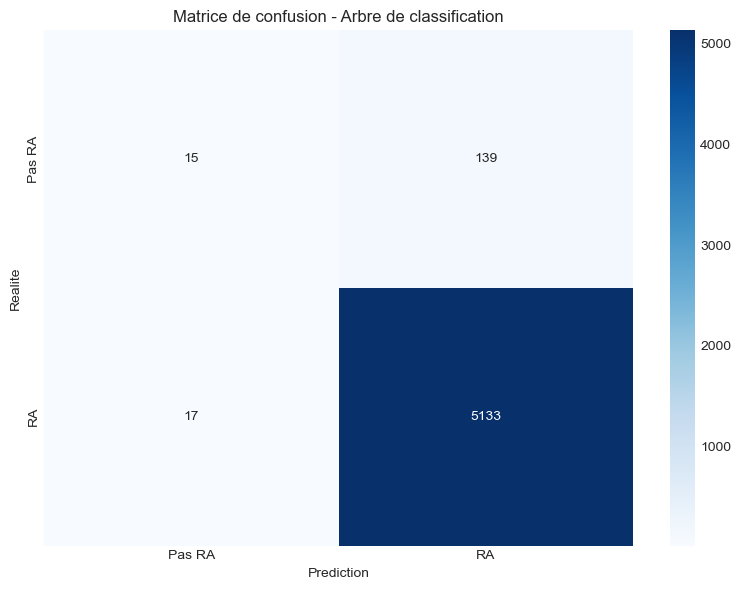

In [14]:
# Matrice de confusion
cm = confusion_matrix(y_test_flag, y_pred_flag)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pas RA', 'RA'], yticklabels=['Pas RA', 'RA'])
plt.xlabel('Prediction')
plt.ylabel('Realite')
plt.title('Matrice de confusion - Arbre de classification')
plt.tight_layout()
plt.show()

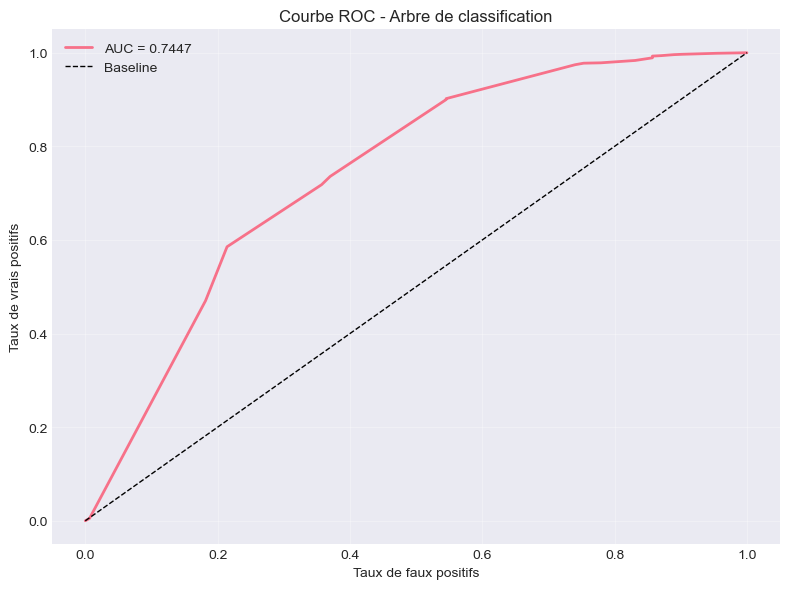

In [15]:
# Courbe ROC
fpr, tpr, _ = roc_curve(y_test_flag, y_pred_proba_flag)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc_score(y_test_flag, y_pred_proba_flag):.4f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Baseline')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC - Arbre de classification')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

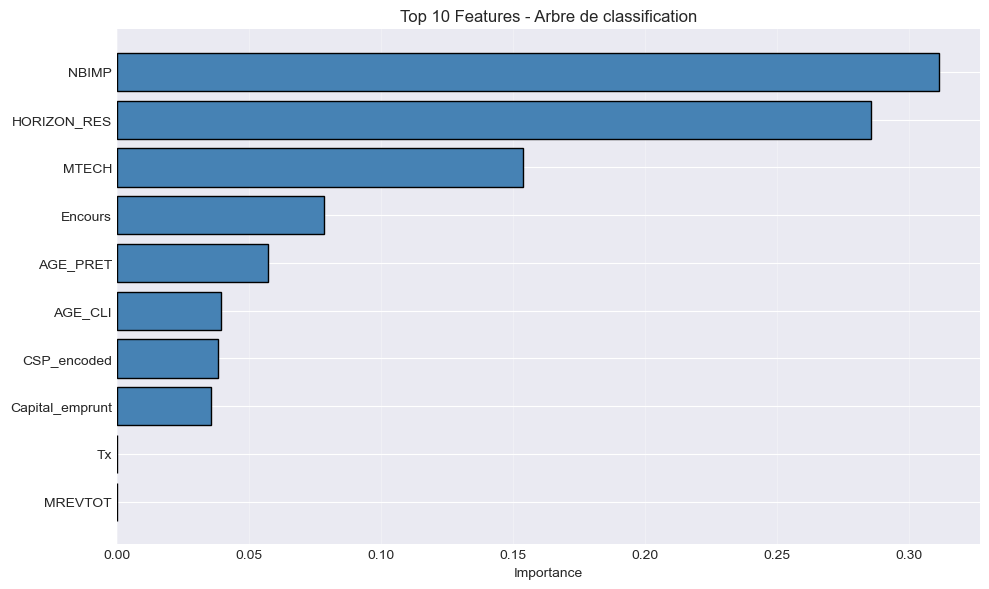

In [16]:
# Feature importance
importances_clf = pd.DataFrame({
    'Feature': model_features,
    'Importance': dt_clf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importances_clf['Feature'][:10], importances_clf['Importance'][:10], 
         color='steelblue', edgecolor='black')
plt.xlabel('Importance')
plt.title('Top 10 Features - Arbre de classification')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 5.2 : Arbre de decision - Regression ER_obs

In [17]:
dt_reg = DecisionTreeRegressor(max_depth=5, min_samples_split=50, 
                                min_samples_leaf=20, random_state=42)
dt_reg.fit(X_train_er, y_train_er)

y_pred_er_dt = dt_reg.predict(X_test_er)

mse = mean_squared_error(y_test_er, y_pred_er_dt)
mae = mean_absolute_error(y_test_er, y_pred_er_dt)
r2 = r2_score(y_test_er, y_pred_er_dt)

print("RESULTATS - ARBRE DE REGRESSION\n")
print(f"RMSE : {np.sqrt(mse):.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")

RESULTATS - ARBRE DE REGRESSION

RMSE : 0.2370
MAE  : 0.1304
R2   : 0.5765


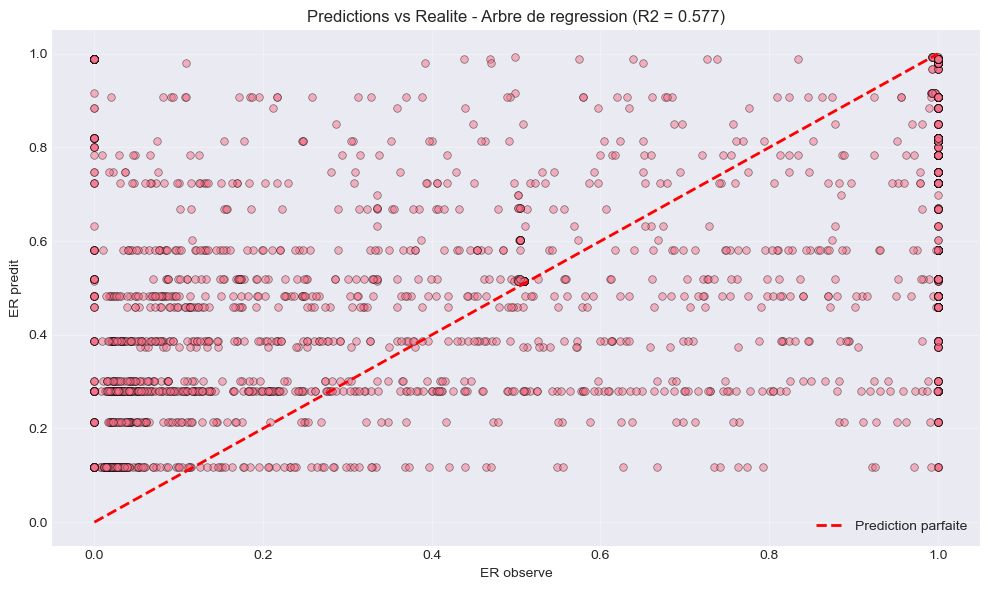

In [18]:
# Predictions vs realite
plt.figure(figsize=(10, 6))
plt.scatter(y_test_er, y_pred_er_dt, alpha=0.5, s=30, edgecolors='black', linewidth=0.5)
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Prediction parfaite')
plt.xlabel('ER observe')
plt.ylabel('ER predit')
plt.title(f'Predictions vs Realite - Arbre de regression (R2 = {r2:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

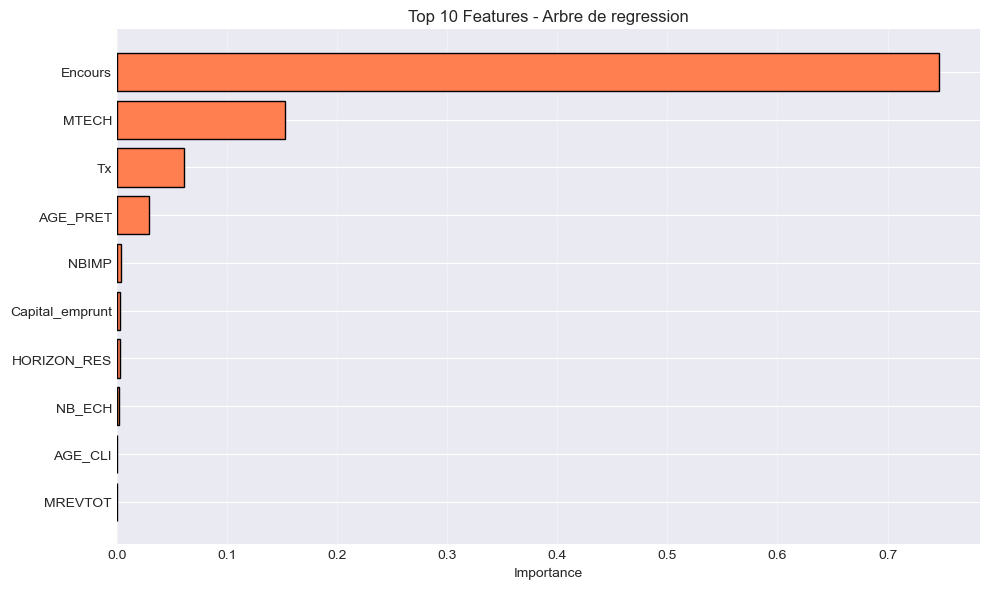

In [19]:
# Feature importance
importances_reg = pd.DataFrame({
    'Feature': model_features,
    'Importance': dt_reg.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importances_reg['Feature'][:10], importances_reg['Importance'][:10], 
         color='coral', edgecolor='black')
plt.xlabel('Importance')
plt.title('Top 10 Features - Arbre de regression')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## SECTION 6 : RANDOM FOREST

### 6.1 : Random Forest - Classification FLAG_ER

In [20]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                 min_samples_split=20, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train_flag)

y_pred_rf_flag = rf_clf.predict(X_test)
y_pred_proba_rf_flag = rf_clf.predict_proba(X_test)[:, 1]

print("RESULTATS - RANDOM FOREST CLASSIFICATION\n")
print(classification_report(y_test_flag, y_pred_rf_flag, target_names=['Pas RA', 'RA']))
print(f"AUC-ROC : {roc_auc_score(y_test_flag, y_pred_proba_rf_flag):.4f}")

RESULTATS - RANDOM FOREST CLASSIFICATION

              precision    recall  f1-score   support

      Pas RA       0.55      0.04      0.07       154
          RA       0.97      1.00      0.99      5150

    accuracy                           0.97      5304
   macro avg       0.76      0.52      0.53      5304
weighted avg       0.96      0.97      0.96      5304

AUC-ROC : 0.7811


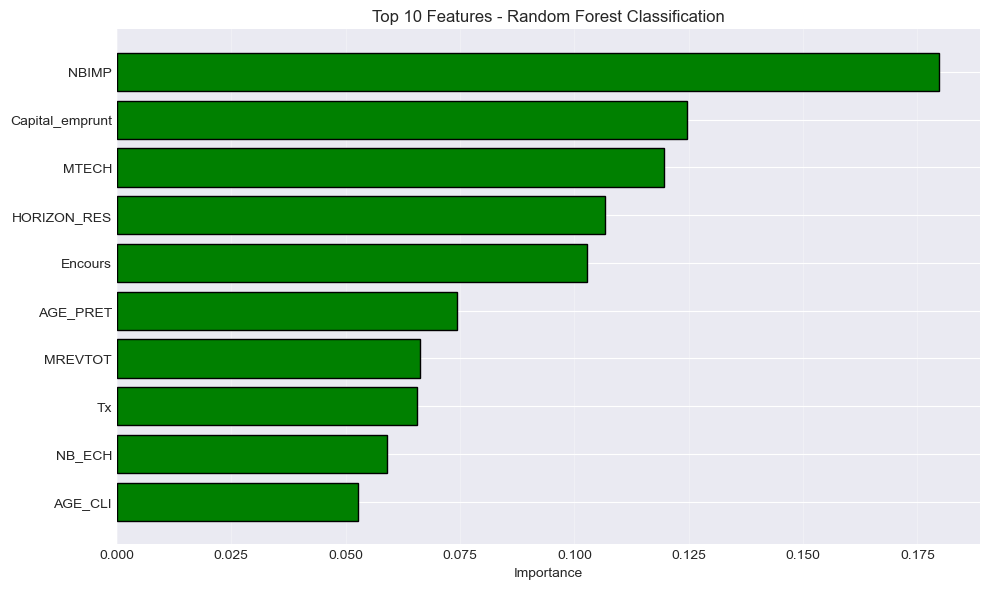

In [21]:
# Feature importance
importances_rf_clf = pd.DataFrame({
    'Feature': model_features,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importances_rf_clf['Feature'][:10], importances_rf_clf['Importance'][:10], 
         color='green', edgecolor='black')
plt.xlabel('Importance')
plt.title('Top 10 Features - Random Forest Classification')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 6.2 : Random Forest - Regression ER_obs

In [22]:
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, 
                                min_samples_split=20, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_er, y_train_er)

y_pred_rf_er = rf_reg.predict(X_test_er)

mse_rf = mean_squared_error(y_test_er, y_pred_rf_er)
mae_rf = mean_absolute_error(y_test_er, y_pred_rf_er)
r2_rf = r2_score(y_test_er, y_pred_rf_er)

print("RESULTATS - RANDOM FOREST REGRESSION\n")
print(f"RMSE : {np.sqrt(mse_rf):.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R2   : {r2_rf:.4f}")

RESULTATS - RANDOM FOREST REGRESSION

RMSE : 0.2264
MAE  : 0.1214
R2   : 0.6135


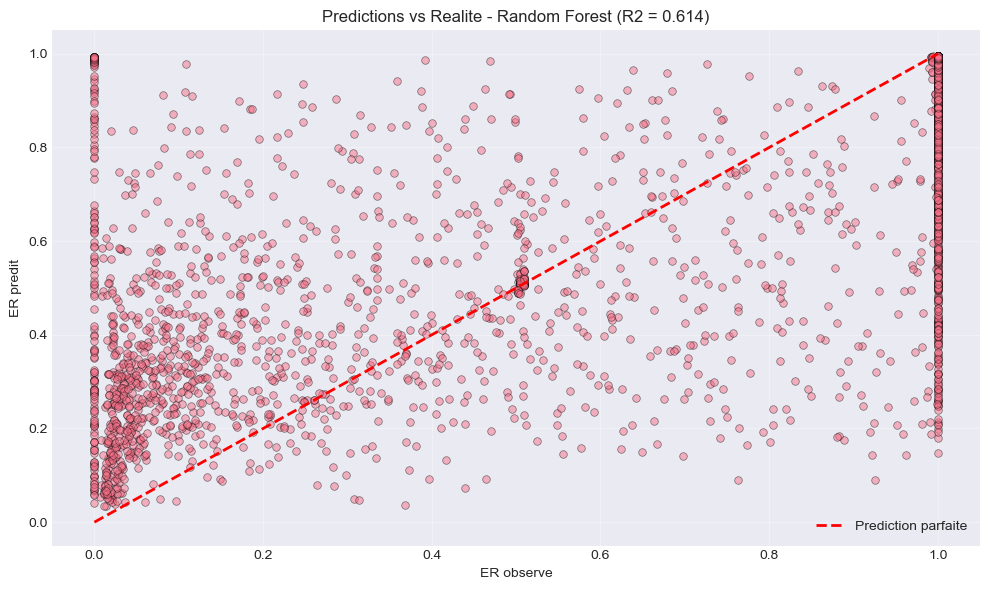

In [23]:
# Predictions vs realite
plt.figure(figsize=(10, 6))
plt.scatter(y_test_er, y_pred_rf_er, alpha=0.5, s=30, edgecolors='black', linewidth=0.5)
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Prediction parfaite')
plt.xlabel('ER observe')
plt.ylabel('ER predit')
plt.title(f'Predictions vs Realite - Random Forest (R2 = {r2_rf:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

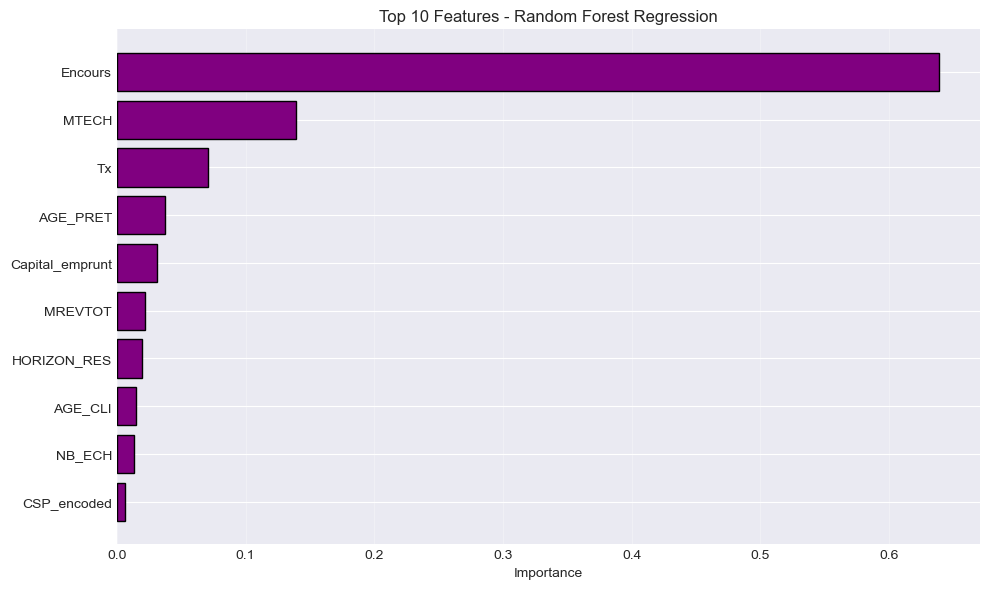

In [24]:
# Feature importance
importances_rf_reg = pd.DataFrame({
    'Feature': model_features,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importances_rf_reg['Feature'][:10], importances_rf_reg['Importance'][:10], 
         color='purple', edgecolor='black')
plt.xlabel('Importance')
plt.title('Top 10 Features - Random Forest Regression')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## SECTION 7 : GRADIENT BOOSTING

### 7.1 : Gradient Boosting - Classification FLAG_ER

In [25]:
gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=5, 
                                     learning_rate=0.1, random_state=42)
gb_clf.fit(X_train, y_train_flag)

y_pred_gb_flag = gb_clf.predict(X_test)
y_pred_proba_gb_flag = gb_clf.predict_proba(X_test)[:, 1]

print("RESULTATS - GRADIENT BOOSTING CLASSIFICATION\n")
print(classification_report(y_test_flag, y_pred_gb_flag, target_names=['Pas RA', 'RA']))
print(f"AUC-ROC : {roc_auc_score(y_test_flag, y_pred_proba_gb_flag):.4f}")

RESULTATS - GRADIENT BOOSTING CLASSIFICATION

              precision    recall  f1-score   support

      Pas RA       0.28      0.08      0.12       154
          RA       0.97      0.99      0.98      5150

    accuracy                           0.97      5304
   macro avg       0.63      0.54      0.55      5304
weighted avg       0.95      0.97      0.96      5304

AUC-ROC : 0.7851


### 7.2 : Gradient Boosting - Regression ER_obs

In [26]:
gb_reg = GradientBoostingRegressor(n_estimators=100, max_depth=5, 
                                    learning_rate=0.1, random_state=42)
gb_reg.fit(X_train_er, y_train_er)

y_pred_gb_er = gb_reg.predict(X_test_er)

mse_gb = mean_squared_error(y_test_er, y_pred_gb_er)
mae_gb = mean_absolute_error(y_test_er, y_pred_gb_er)
r2_gb = r2_score(y_test_er, y_pred_gb_er)

print("RESULTATS - GRADIENT BOOSTING REGRESSION\n")
print(f"RMSE : {np.sqrt(mse_gb):.4f}")
print(f"MAE  : {mae_gb:.4f}")
print(f"R2   : {r2_gb:.4f}")

RESULTATS - GRADIENT BOOSTING REGRESSION

RMSE : 0.2257
MAE  : 0.1216
R2   : 0.6161


## SECTION 8 : COMPARAISON DES MODELES

COMPARAISON CLASSIFICATION (FLAG_ER)

           Modele  AUC-ROC
Arbre de decision 0.744675
    Random Forest 0.781127
Gradient Boosting 0.785114


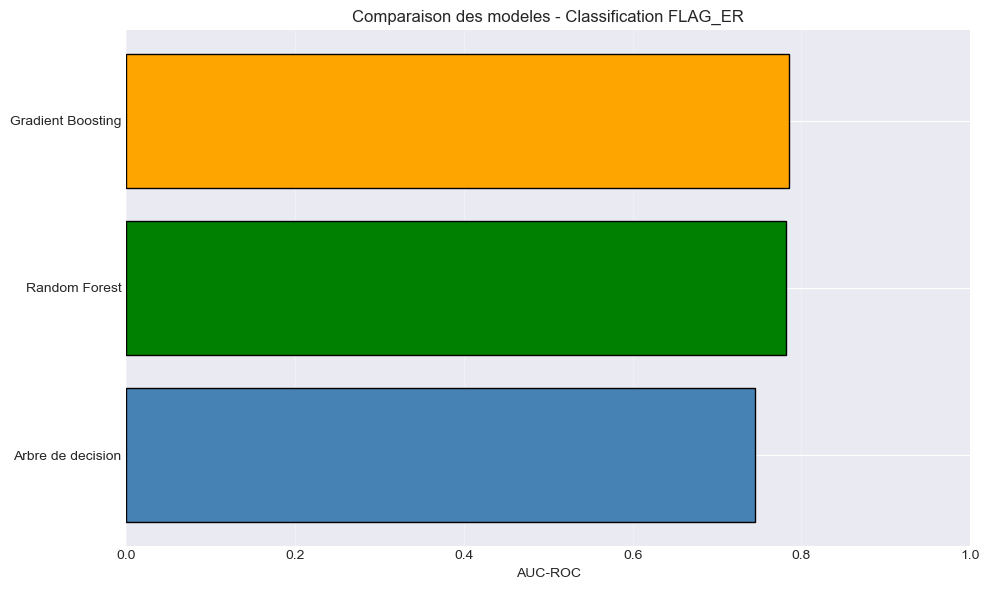

In [27]:
# Comparaison CLASSIFICATION
results_clf = pd.DataFrame({
    'Modele': ['Arbre de decision', 'Random Forest', 'Gradient Boosting'],
    'AUC-ROC': [
        roc_auc_score(y_test_flag, y_pred_proba_flag),
        roc_auc_score(y_test_flag, y_pred_proba_rf_flag),
        roc_auc_score(y_test_flag, y_pred_proba_gb_flag)
    ]
})

print("COMPARAISON CLASSIFICATION (FLAG_ER)\n")
print(results_clf.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(results_clf['Modele'], results_clf['AUC-ROC'], 
         color=['steelblue', 'green', 'orange'], edgecolor='black')
plt.xlabel('AUC-ROC')
plt.title('Comparaison des modeles - Classification FLAG_ER')
plt.xlim(0, 1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

COMPARAISON REGRESSION (ER_obs)

           Modele     RMSE      MAE       R2
Arbre de decision 0.237013 0.130370 0.576520
    Random Forest 0.226416 0.121402 0.613544
Gradient Boosting 0.225666 0.121624 0.616098


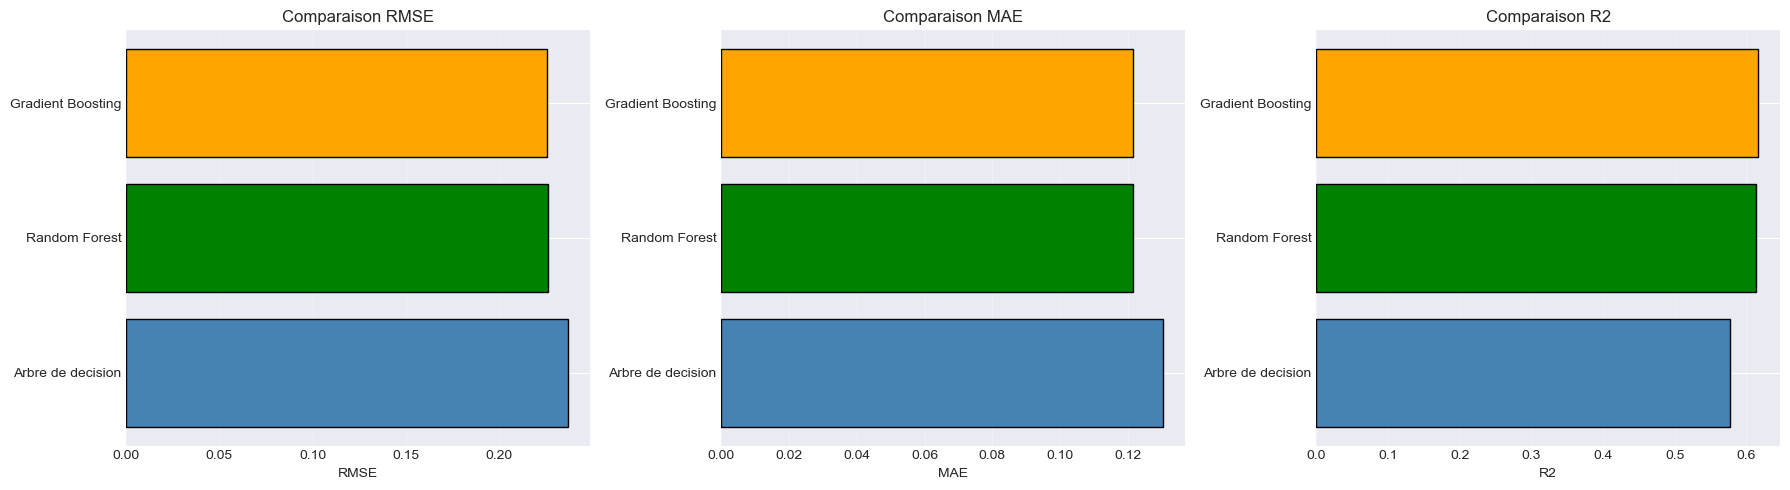

In [28]:
# Comparaison REGRESSION
results_reg = pd.DataFrame({
    'Modele': ['Arbre de decision', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [np.sqrt(mse), np.sqrt(mse_rf), np.sqrt(mse_gb)],
    'MAE': [mae, mae_rf, mae_gb],
    'R2': [r2, r2_rf, r2_gb]
})

print("COMPARAISON REGRESSION (ER_obs)\n")
print(results_reg.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(results_reg['Modele'], results_reg['RMSE'], 
             color=['steelblue', 'green', 'orange'], edgecolor='black')
axes[0].set_xlabel('RMSE')
axes[0].set_title('Comparaison RMSE')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(results_reg['Modele'], results_reg['MAE'], 
             color=['steelblue', 'green', 'orange'], edgecolor='black')
axes[1].set_xlabel('MAE')
axes[1].set_title('Comparaison MAE')
axes[1].grid(True, alpha=0.3, axis='x')

axes[2].barh(results_reg['Modele'], results_reg['R2'], 
             color=['steelblue', 'green', 'orange'], edgecolor='black')
axes[2].set_xlabel('R2')
axes[2].set_title('Comparaison R2')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## CONCLUSION

Ce notebook a presente une modelisation complete du taux de remboursement anticipe (ER) avec :

1. **Formule correcte** : ER = RA / Encours (avec Encours = Capital_emprunt - Montant_rembourse)
2. **Analyse exploratoire** : Distribution, evolution par age du pret, par taux d'interet
3. **Segmentation** : Clustering K-Means pour identifier des profils homogenes
4. **Modelisation** : Arbres de decision, Random Forest, Gradient Boosting
5. **Comparaison** : Evaluation des performances (AUC-ROC, RMSE, MAE, R2)

Les modeles d'ensemble (Random Forest, Gradient Boosting) surpassent les arbres simples.
La feature importance revele que AGE_PRET, Encours et HORIZON_RES sont les variables les plus predictives.